# Exercise 3: KNN and the Bias–Variance Tradeoff


```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activity works
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_03/exercise_03_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_03/exercise_03_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps the embedded
activity for a link back to this page.
```


## What this notebook covers

This is Exercise 3 of *Machine Learning for Neuroscience*. **K-nearest
neighbours (KNN)** predicts a new participant's outcome from the outcomes of
the training participants who look most similar:

- for **regression**, KNN averages the outcome of the `k` nearest training
  participants;
- KNN can also do **classification**, voting among the `k` nearest labels
  instead of averaging -- you will see that later; this notebook is
  regression only.

This practice uses `k` -- the number of neighbours -- to make the
**bias–variance tradeoff** concrete: a small `k` is flexible (low bias,
high variance); a large `k` is smooth (higher bias, low variance).

In this notebook you will:

1. reuse Exercise 2's data table, target, feature recipe, and locked
   train/test split;
2. fit one standardized KNN regression workflow at `k = 20`, the value used
   in this worked example, on the training participants, and compare it
   with Exercise 2's linear regression on the exact same data;
3. interactively compare honest evaluation with resubstitution and with a
   deliberately invalid leakage score, across every `k`;
4. see the classic bias–variance tradeoff as a labelled, conceptual curve;
5. compute an empirical curve, from this dataset, of fitting and validation
   error across every `k` from 1 to every participant in a development
   fitting set;
6. explore that curve yourself with a browser activity, including how
   predictions vary across different training samples.

**Prerequisites:** Exercise 2's train/test workflow, R² and MSE, and
`Pipeline` / `fit` / `predict` in scikit-learn.


## 1. Our data table

This is the same ABIDE-II data table Exercise 2 uses: one **row per
participant**, phenotype columns (including the target, `age`), and brain
columns (`fsCT`, `fsArea`, `fsVol`, `fsLGI`, one HCP-MMP1 cortical region per
hemisphere). See Exercise 2 for the full provenance and column-by-column
discussion; this notebook only reloads the table and previews it.


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. Nothing
# here is repository-specific. Same data and provenance as Exercise 2.
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"data table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")


modelling table: 1004 participants x 1446 columns


In [2]:
# A compact preview only -- Exercise 2 already covers this table in full.
preview_cols = ["subject", "site", "group", "age", "sex", "fsCT_L_46_ROI"]
display(model_df[preview_cols].head(3))
print("age available for", int(model_df["age"].notna().sum()), "of", len(model_df), "participants")


,subject,site,group,age,sex,fsCT_L_46_ROI
0,29293,ABIDEII-KKI_1,1.0,8.893151,2.0,2.366
1,28997,ABIDEII-OHSU_1,1.0,12.000000,2.0,2.579
2,28845,ABIDEII-GU_1,2.0,8.390000,1.0,2.690


age available for 1004 of 1004 participants


## 2. One standard KNN regression workflow

**Target:** `age`, in years -- Exercise 2's own outcome. **Features:** the
exact same recipe as Exercise 2's worked example -- every one of the 360
cortical atlas parcels for cortical thickness (`fsCT`), bilateral. **Split:**
the exact same locked 75/25 train/test split as Exercise 2
(`train_test_split(test_size=0.25, random_state=42, stratify=group)`),
re-derived here from the same data so it lands on the identical 753
training and 251 test participants.

KNN regression predicts

$$\hat{y}(x_0)=\frac{1}{k}\sum_{i\in\mathcal{N}_k(x_0)}y_i,$$

the average outcome of the `k` training participants whose **features** are
closest to $x_0$. The neighbourhood is found using predictors only -- a new
participant's `age` is never used to find their neighbours.

Feature scaling matters here more directly than it did for linear
regression: KNN measures distance in feature space, and an unscaled feature
with large numeric range would dominate that distance just because of its
units, not because it is more informative. `StandardScaler` belongs inside
the `Pipeline` and must be fit on the training data only, exactly like
Exercise 2.

**A short note on dimensionality.** In very high-dimensional feature spaces,
most pairs of points end up roughly equally far apart, so "nearest
neighbour" can stop meaning much -- the *curse of dimensionality*. This
recipe's 360 standardized features are not astronomically high-dimensional
for 753 training rows, and KNN works well here at
k = 20; a higher-dimensional recipe or a smaller sample could behave
differently.


In [3]:
# The full set of 360 cortical-thickness columns -- identical recipe and
# code to Exercise 2's Section 2.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)           # brain-only
assert "age" not in FEATURES                                  # no target leakage
print(f"{len(FEATURES)} features, e.g. {FEATURES[:3]}")


360 features, e.g. ['fsCT_L_V1_ROI', 'fsCT_L_MST_ROI', 'fsCT_L_V6_ROI']


In [4]:
# Brain-only X and target y, then the SAME fixed, stratified split as
# Exercise 2 (groups is carried through only so Section 5 can re-split the
# training partition later; it does not change X_train/X_test/y_train/y_test).
has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()      # 1 = autism, 2 = control

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")


n_train = 753   n_test = 251   n_features = 360


```{admonition} Think first
:class: think-first
Exercise 2's linear regression scored held-out R² = 0.469 on this exact
split and feature set. Before running KNN: do you expect it to score
higher, lower, or about the same -- and why? (Hint: think about what each
model assumes about how brain structure relates to age.)
```


### Choosing k for this example

In this introductory exercise, we choose one model setting in advance, fit
the model using the training participants, and evaluate it on the test
participants. A later lesson will introduce systematic methods for
selecting model settings.

```python
K_EXAMPLE = 20
```

This is simply the value used for this worked example, chosen before the
held-out result below is computed. It is not optimized, tuned, or chosen
because it performed best.


In [5]:
K_EXAMPLE = 20

knn_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=K_EXAMPLE))
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
print(f"k = {K_EXAMPLE}")
print(f"held-out R^2 = {test_r2:.3f}")
print(f"held-out MSE = {test_mse:.1f}  (RMSE {test_mse**0.5:.1f} years)")


k = 20
held-out R^2 = 0.664
held-out MSE = 31.4  (RMSE 5.6 years)


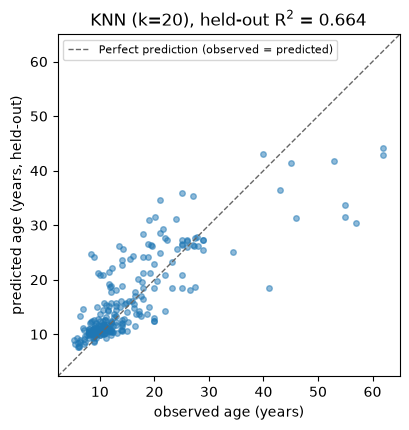

In [6]:
# Observed vs predicted on the test set, with the perfect-prediction diagonal.
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lims = [min(y_test.min(), y_pred.min()) - 3, max(y_test.max(), y_pred.max()) + 3]
ax.plot(lims, lims, "--", color="0.4", lw=1, label="Perfect prediction (observed = predicted)")
ax.scatter(y_test, y_pred, s=16, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("observed age (years)"); ax.set_ylabel("predicted age (years, held-out)")
ax.set_title(f"KNN (k={K_EXAMPLE}), held-out R$^2$ = {test_r2:.3f}")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


A few things to hold onto:

- KNN with k = 20 scores a genuinely **positive held-out
  R²** on this recipe -- no curse-of-dimensionality problem here;
- unlike the linear-regression hyperplane, KNN makes no assumption about the
  *shape* of the relationship between features and age -- it only assumes
  that similar brain measurements go with similar ages;
- this is still a random-participant split from the same 17 ABIDE-II sites,
  so it says nothing about generalisation to a new scanner or site.

**Compared with Exercise 2.** On these exact same 753 training and 251 test
participants, the exact same 360-feature recipe, and the exact same target:


In [7]:
# For comparison only -- exact same split/recipe/target as Exercise 2's
# Section 2, refit here so the comparison is self-contained.
ols_compare = make_pipeline(StandardScaler(), LinearRegression())
ols_compare.fit(X_train, y_train)
ols_r2 = r2_score(y_test, ols_compare.predict(X_test))
print(f"Exercise 2 linear regression   held-out R^2 = {ols_r2:.3f}")
print(f"This notebook's KNN (k={K_EXAMPLE})    held-out R^2 = {test_r2:.3f}")


Exercise 2 linear regression   held-out R^2 = 0.469
This notebook's KNN (k=20)    held-out R^2 = 0.664


KNN scores higher than linear regression **on this specific recipe and
dataset**. That is one comparison, not a universal claim that KNN beats
linear regression -- a different feature set, sample size, or outcome could
easily reverse it. What it does show is that a non-parametric method with no
assumption about the relationship's shape found real, usable structure here.


## 3. Honest evaluation versus invalid alternatives

Same fixed split, same 360-feature recipe, but now for **every** `k`, not
just one: `k` also changes how *dramatically* resubstitution and leakage
inflate performance, and the interactive activity below lets you see that
directly instead of reading it off two static tables.

| | fit on | evaluate on | what it estimates |
|---|---|---|---|
| **A. Valid** | training rows | untouched test rows | performance on new participants |
| **B. Resubstitution** | training rows | those same training rows | how well it fits data it has seen (a diagnostic, not a generalisation estimate) |
| **C. Invalid (leakage)** | **test rows** | those same test rows | nothing usable -- the data used to fit cannot also give an honest score |

```{admonition} Think first
:class: think-first
At k = 20 (Section 2's worked-example value), predict the order of A, B, and C
from largest to smallest R². Then predict what changes about that ordering
at the smallest possible `k`, and why.
```


<iframe
  title="Interactive honest-vs-invalid KNN evaluation for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/knn_abc.json"
  loading="lazy"
  width="100%"
  height="900"
  class="ml-activity"
  style="width: 100%;"
></iframe>


The activity recomputes real predictions, R², and MSE for all three panels
at whichever `k` you choose -- nothing is a canned label. A few things to
notice as you move `k`:

- **at `k = 1`, B and C are exactly perfect (R² = 1.000):** every evaluated
  point is its own nearest neighbour, at distance zero, so the prediction
  reproduces the observation by construction, not because anything was
  learned;
- **A at `k = 1` is not perfect:** the test participants it evaluates were
  never used for fitting, so `k = 1`'s perfect B/C scores are the clearest
  possible evidence that evaluating on fitted data is invalid -- not evidence
  that KNN generalises perfectly;
- **increasing `k` averages more observations,** which usually reduces this
  dramatic resubstitution effect -- watch how much closer A, B, and C stay to
  each other as `k` grows past k = 20 (Section 2's worked-example value).


## 4. The classic bias–variance tradeoff

For a model $\hat f$ predicting outcome $Y$ from features $X$, the expected
squared prediction error on a new observation decomposes as

$$\mathbb{E}\left[(Y-\hat f(X))^2\right]
=\operatorname{Bias}(\hat f(X))^2
+\operatorname{Var}(\hat f(X))
+\sigma^2.$$

For KNN, `k` controls flexibility directly:

- **small `k`** -> high flexibility, low bias, high variance (the model
  chases whichever few neighbours happened to be closest);
- **large `k`** -> low flexibility, higher bias, lower variance (the model
  averages over so many neighbours it stops reacting to any one of them);
- **training error alone** keeps falling as flexibility increases (Section
  3 showed `k = 1` reaching a perfect resubstitution score), so it favours
  excessive flexibility and cannot be used to choose `k`;
- **expected test error** is minimised at some intermediate flexibility,
  where the falling bias² and the rising variance trade off against each
  other.

This is a **general tendency of KNN**, not a guarantee for every finite
sample: the curve below is a **labelled, conceptual illustration** of the
tradeoff -- smooth idealised curves, not a measurement from the ABIDE data.
Sections 5 and 6 compute observable, honestly-labelled analogues *from this
dataset*.


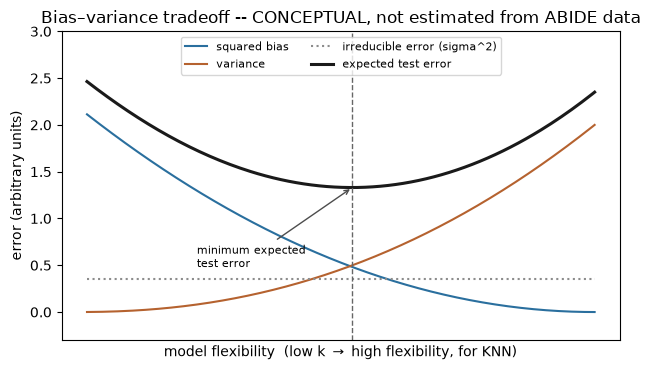

In [8]:
# CONCEPTUAL illustration only -- smooth idealised curves, not measured from
# the ABIDE data. Sections 5-6 compute the empirical analogues.
flexibility = np.linspace(0.02, 1, 200)          # 0 = very smooth, 1 = very flexible
bias_sq = (1 - flexibility) ** 2 * 2.2
variance = flexibility ** 2.2 * 2.0
irreducible = np.full_like(flexibility, 0.35)
expected_test_error = bias_sq + variance + irreducible

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(flexibility, bias_sq, label="squared bias", color="#2a6f9e")
ax.plot(flexibility, variance, label="variance", color="#b5622f")
ax.plot(flexibility, irreducible, label="irreducible error (sigma^2)", color="0.55", ls=":")
ax.plot(flexibility, expected_test_error, label="expected test error", color="0.1", lw=2.2)
best = flexibility[np.argmin(expected_test_error)]
ax.axvline(best, color="0.4", lw=1, ls="--")
ax.annotate("minimum expected\ntest error", xy=(best, expected_test_error.min()),
            xytext=(best - 0.30, expected_test_error.min() - 0.85), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xlabel("model flexibility  (low k $\\to$ high flexibility, for KNN)")
ax.set_ylabel("error (arbitrary units)")
ax.set_title("Bias\u2013variance tradeoff -- CONCEPTUAL, not estimated from ABIDE data")
ax.set_xticks([])
ax.set_ylim(-0.3, 3.0)
ax.legend(fontsize=8, loc="upper center", ncol=2)
plt.tight_layout(); plt.show()


## 5. From k = 1 to every participant: an empirical curve

This section builds a **separate, deterministic development demonstration**
using only the outer-**training** partition (`X_train`, `y_train`, 753
rows) -- the outer test set from Sections 2–3 is never touched here.

Split the training partition itself into a **fitting subset** and a
**validation subset**:

> `N_fit` = number of participants used to fit KNN in this demonstration.

Every integer `k` from 1 through `N_fit` is evaluated on both the fitting
subset (resubstitution) and the validation subset, using the
sort-distances-once-then-cumulative-sum trick (Section 6 reuses the same
idea, and its plain-language description, in the browser).


In [9]:
FIT_TEST_SIZE = 0.25
FIT_RANDOM_STATE = 7   # independent of the outer split's random_state=42
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=FIT_TEST_SIZE, random_state=FIT_RANDOM_STATE, stratify=groups_train
)
N_FIT = len(y_fit)
N_VAL = len(y_val)
print(f"N_fit = {N_FIT}   N_val = {N_VAL}   (from the {len(y_train)}-row outer-training partition only)")


N_fit = 564   N_val = 189   (from the 753-row outer-training partition only)


In [10]:
# Scale using the fitting subset only, then sort each query point's distances
# to every fitting point ONCE and derive predictions for every k from a
# cumulative mean -- far cheaper than refitting KNeighborsRegressor N_fit times.
t0 = time.time()
scaler_dev = StandardScaler().fit(X_fit)
Xf = scaler_dev.transform(X_fit)
Xv = scaler_dev.transform(X_val)

def sorted_neighbor_targets(X_query, X_ref, y_ref):
    d = np.linalg.norm(X_query[:, None, :] - X_ref[None, :, :], axis=2)
    order = np.argsort(d, axis=1, kind="stable")
    return y_ref[order]

sorted_val = sorted_neighbor_targets(Xv, Xf, y_fit)   # N_val x N_fit, nearest first
sorted_fit = sorted_neighbor_targets(Xf, Xf, y_fit)   # N_fit x N_fit (self-inclusive)

def r2_mse_curve(sorted_targets, observed):
    cum = np.cumsum(sorted_targets, axis=1)
    ks = np.arange(1, sorted_targets.shape[1] + 1)
    pred_all_k = cum / ks[None, :]
    ss_res = np.sum((observed[:, None] - pred_all_k) ** 2, axis=0)
    ss_tot = np.sum((observed - observed.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    mse = np.mean((observed[:, None] - pred_all_k) ** 2, axis=0)
    return r2, mse

val_r2, val_mse = r2_mse_curve(sorted_val, y_val)
fit_r2, fit_mse = r2_mse_curve(sorted_fit, y_fit)
ks = np.arange(1, N_FIT + 1)
val_optimal_k = int(ks[np.argmax(val_r2)])
print(f"computed {N_FIT} values of k for {N_FIT} fitting and {N_VAL} validation points in {time.time() - t0:.1f}s")
print(f"k=1                        fit R^2={fit_r2[0]:.3f}   val R^2={val_r2[0]:.3f}")
print(f"k={val_optimal_k} (lowest validation error)  val R^2={val_r2[val_optimal_k - 1]:.3f}")
print(f"k=N_fit={N_FIT}                fit R^2={fit_r2[-1]:.3f}   val R^2={val_r2[-1]:.3f}")


computed 564 values of k for 564 fitting and 189 validation points in 1.2s
k=1                        fit R^2=1.000   val R^2=0.279
k=17 (lowest validation error)  val R^2=0.634
k=N_fit=564                fit R^2=-0.000   val R^2=-0.004


In [11]:
# Verify the k = N_fit endpoint explicitly: with every fitting participant as
# a neighbour, "the k nearest" is just "everyone", so the prediction is the
# SAME constant -- the fitting-set mean age -- for every validation participant.
pred_val_at_k_nfit = np.cumsum(sorted_val, axis=1)[:, -1] / N_FIT
assert np.allclose(pred_val_at_k_nfit, y_fit.mean())
print(f"k = N_fit: every validation prediction equals the fitting-set mean, {y_fit.mean():.3f} years")


k = N_fit: every validation prediction equals the fitting-set mean, 15.192 years


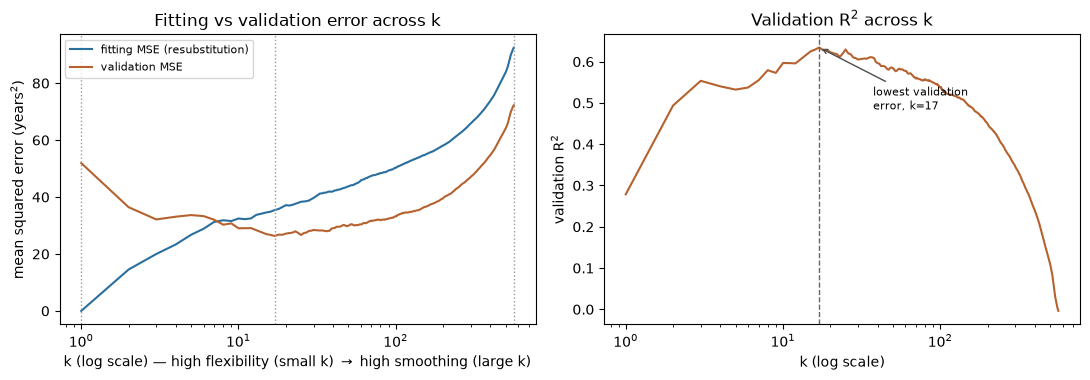

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

ax = axes[0]
ax.plot(ks, fit_mse, label="fitting MSE (resubstitution)", color="#2a6f9e")
ax.plot(ks, val_mse, label="validation MSE", color="#b5622f")
ax.set_xscale("log")
ax.set_xlabel("k (log scale) \u2014 high flexibility (small k) $\\to$ high smoothing (large k)")
ax.set_ylabel("mean squared error (years$^2$)")
for k_mark, label in [(1, "k=1"), (val_optimal_k, "lowest validation error"), (N_FIT, "k=N_fit")]:
    ax.axvline(k_mark, color="0.6", lw=1, ls=":")
ax.legend(fontsize=8)
ax.set_title("Fitting vs validation error across k")

ax = axes[1]
ax.plot(ks, val_r2, color="#b5622f")
ax.axvline(val_optimal_k, color="0.4", lw=1, ls="--")
ax.annotate(f"lowest validation\nerror, k={val_optimal_k}", xy=(val_optimal_k, val_r2[val_optimal_k - 1]),
            xytext=(val_optimal_k * 2.2, val_r2[val_optimal_k - 1] - 0.15), fontsize=8,
            arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xscale("log")
ax.set_xlabel("k (log scale)")
ax.set_ylabel("validation R$^2$")
ax.set_title("Validation R$^2$ across k")

plt.tight_layout(); plt.show()


```{admonition} What this curve shows -- and does not
:class: note
Fitting error keeps falling as `k` shrinks (perfect at `k = 1`, exactly the
resubstitution optimism Section 3 demonstrated) while validation error is
lowest at an intermediate `k` and rises again toward both ends -- **behaviour
consistent with** the bias–variance tradeoff. It does not **directly
estimate** bias and variance: the true population relationship between
cortical structure and age is unknown, and this is one observational sample,
not repeated draws from that population. The `k` with the lowest validation error here need not match the k = 20
worked-example value from Section 2 -- they come from different splits of
different data and are not meant to agree exactly. Repeatedly inspecting this
curve is for illustration here; it is not used to claim a final optimized
score.

This development curve is exploratory. It never retunes or replaces the
Section 2 model: the outer test set stays locked, and the `k` reported there
is the notebook's one honest number.
```


## 6. Explore k yourself

The central `k`-complexity relationship, stated plainly: a **larger `k`**
averages more neighbours and approaches predicting the fitting-set mean -- a
**simpler, smoother model** with lower variance but higher bias. A
**smaller `k`** follows individual fitting participants more closely -- a
**more flexible, more complex model** with lower bias but higher variance and
a greater risk of overfitting. "Lower bias" is a general tendency of KNN, not
a guarantee for every finite sample -- the activity below, and Section 3's
activity above, let you watch what actually happens in this one.

The activity below lets you move the same `k` from 1 through `N_fit`
yourself, on the same fitting/validation split as Section 5 -- now with an
exact numeric entry alongside the slider, and three deterministic
alternative training samples so you can see directly how much predictions
depend on *which* participants happened to be drawn for training, at small
and large `k`. Every plot and every number recomputes from the actual
refitted model at your chosen `k` -- nothing is a canned label. The activity
opens at k = 20, the same worked-example value as Section 2, but this is
exploration of model behaviour, not parameter selection: moving the slider
does not choose a final k for the notebook. It runs entirely in the browser,
offline, with no brain features or participant identifiers ever sent
anywhere.


<iframe
  title="Interactive KNN neighbour-count exploration for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/knn_explore.json"
  loading="lazy"
  width="100%"
  height="2700"
  class="ml-activity"
  style="width: 100%;"
></iframe>


## In summary

- KNN regression predicts by averaging the `k` nearest training
  participants' outcomes; `k` directly controls flexibility.
- Fixing `k = 20` in advance, fitting on the training participants, and
  evaluating once on a locked test set is the same honest workflow
  structure Exercise 2 used for linear regression -- only the model family
  changed. A later lesson introduces systematic methods for choosing `k`.
- Resubstitution and leakage inflate performance the same way they did for
  linear regression; how *dramatically* they inflate it depends on `k` --
  the Section 3 activity makes that dependence, and its extreme at `k = 1`,
  directly interactive.
- Small `k` means low bias and high variance; large `k` means higher bias
  and low variance; training error alone cannot choose between them. The
  Section 6 activity's training-sample-sensitivity and binned-calibration
  panels make both halves of that tradeoff separately observable.
- An empirical fitting/validation curve computed from real data is
  **consistent with** the bias–variance tradeoff without being a direct
  measurement of it -- the population relationship is unknown and only one
  sample is available.

Next practice: classification, where KNN votes among neighbours' labels
instead of averaging their values.


### Questions to take away

1. What happens to flexibility when `k` increases?
2. Why can `k = 1` achieve perfect resubstitution performance?
3. Why is that not evidence of good generalisation?
4. What does `k = N_fit` predict for every new participant?
5. Why must scaling be learned only from training data, exactly as in
   Exercise 2?
6. In Section 6, at a small `k`, why do the three training samples' scatter
   plots differ more than they do at a large `k`?
7. In Section 6's binned calibration panel, why does the ensemble's
   prediction line flatten as `k` grows, and which participants does that
   flattening hurt most?
8. Why is a validation curve computed from one dataset not a direct
   measurement of bias and variance?
9. Would the `k` used here necessarily generalise to a completely new
   scanning site? Why or why not?
